In [1]:
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn import datasets
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn import metrics

In [2]:
original = pd.read_csv("plant_health_data.csv")
original

,Timestamp,Plant_ID,Soil_Moisture,Ambient_Temperature,Soil_Temperature,Humidity,Light_Intensity,Soil_pH,Nitrogen_Level,Phosphorus_Level,Potassium_Level,Chlorophyll_Content,Electrochemical_Signal,Plant_Health_Status
0,2024-10-03 10:54:53.407995,1,27.521109,22.240245,21.900435,55.291904,556.172805,5.581955,10.003650,45.806852,39.076199,35.703006,0.941402,High Stress
1,2024-10-03 16:54:53.407995,1,14.835566,21.706763,18.680892,63.949181,596.136721,7.135705,30.712562,25.394393,17.944826,27.993296,0.164899,High Stress
2,2024-10-03 22:54:53.407995,1,17.086362,21.180946,15.392939,67.837956,591.124627,5.656852,29.337002,27.573892,35.706530,43.646308,1.081728,High Stress
3,2024-10-04 04:54:53.407995,1,15.336156,22.593302,22.778394,58.190811,241.412476,5.584523,16.966621,26.180705,26.257746,37.838095,1.186088,High Stress
4,2024-10-04 10:54:53.407995,1,39.822216,28.929001,18.100937,63.772036,444.493830,5.919707,10.944961,37.898907,37.654483,48.265812,1.609805,High Stress
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,2024-11-01 04:54:53.493508,10,29.665780,27.605285,15.381699,54.668196,650.536854,5.715289,29.993107,14.914470,21.560747,24.273224,0.714553,Moderate Stress
1196,2024-11-01 10:54:53.493508,10,15.490782,22.108112,15.221033,61.243143,768.760787,5.958957,45.258678,25.216248,31.940717,30.930676,1.448029,High Stress
1197,2024-11-01 16:54:53.493508,10,23.495723,21.680240,15.499764,40.693671,293.643366,7.419157,38.351189,48.656078,28.473233,38.324484,0.880019,Moderate Stress
1198,2024-11-01 22:54:53.493508,10,30.971675,23.019488,21.934918,41.387107,492.952014,5.855767,49.402550,23.843971,19.750042,46.027529,0.344597,Healthy


In [3]:
#First have to remove data I'm not collecting since it will be useless to my model
right_features = original.drop(['Plant_ID', 'Timestamp','Soil_Temperature','Nitrogen_Level', 'Phosphorus_Level','Potassium_Level','Soil_pH', 'Chlorophyll_Content', 'Electrochemical_Signal'], axis=1)


right_features

,Soil_Moisture,Ambient_Temperature,Humidity,Light_Intensity,Plant_Health_Status
0,27.521109,22.240245,55.291904,556.172805,High Stress
1,14.835566,21.706763,63.949181,596.136721,High Stress
2,17.086362,21.180946,67.837956,591.124627,High Stress
3,15.336156,22.593302,58.190811,241.412476,High Stress
4,39.822216,28.929001,63.772036,444.493830,High Stress
...,...,...,...,...,...
1195,29.665780,27.605285,54.668196,650.536854,Moderate Stress
1196,15.490782,22.108112,61.243143,768.760787,High Stress
1197,23.495723,21.680240,40.693671,293.643366,Moderate Stress
1198,30.971675,23.019488,41.387107,492.952014,Healthy


In [4]:
right_features.dtypes.sort_values()

Soil_Moisture          float64
Ambient_Temperature    float64
Humidity               float64
Light_Intensity        float64
Plant_Health_Status     object
dtype: object

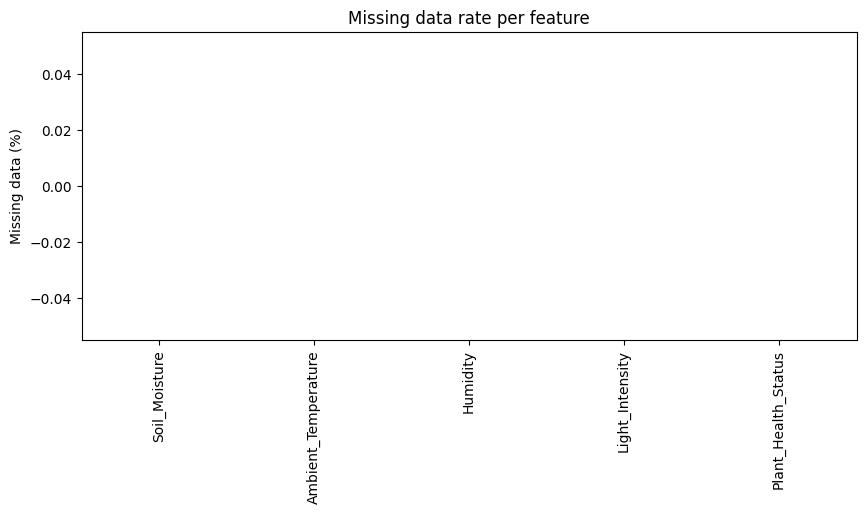

In [5]:
missing_vals = ["", " ", "NA", "N/A", "null", "None", "?"] #Replaces any non nan missing data with nan so it can be used with isna
right_features = right_features.replace(missing_vals, np.nan)

missing_rate = right_features.isna().mean().sort_values(ascending=False) * 100
missing_rate.plot(kind="bar", figsize=(10,4))
plt.ylabel("Missing data (%)")
plt.title("Missing data rate per feature")
plt.show()

#No missing data wonderful

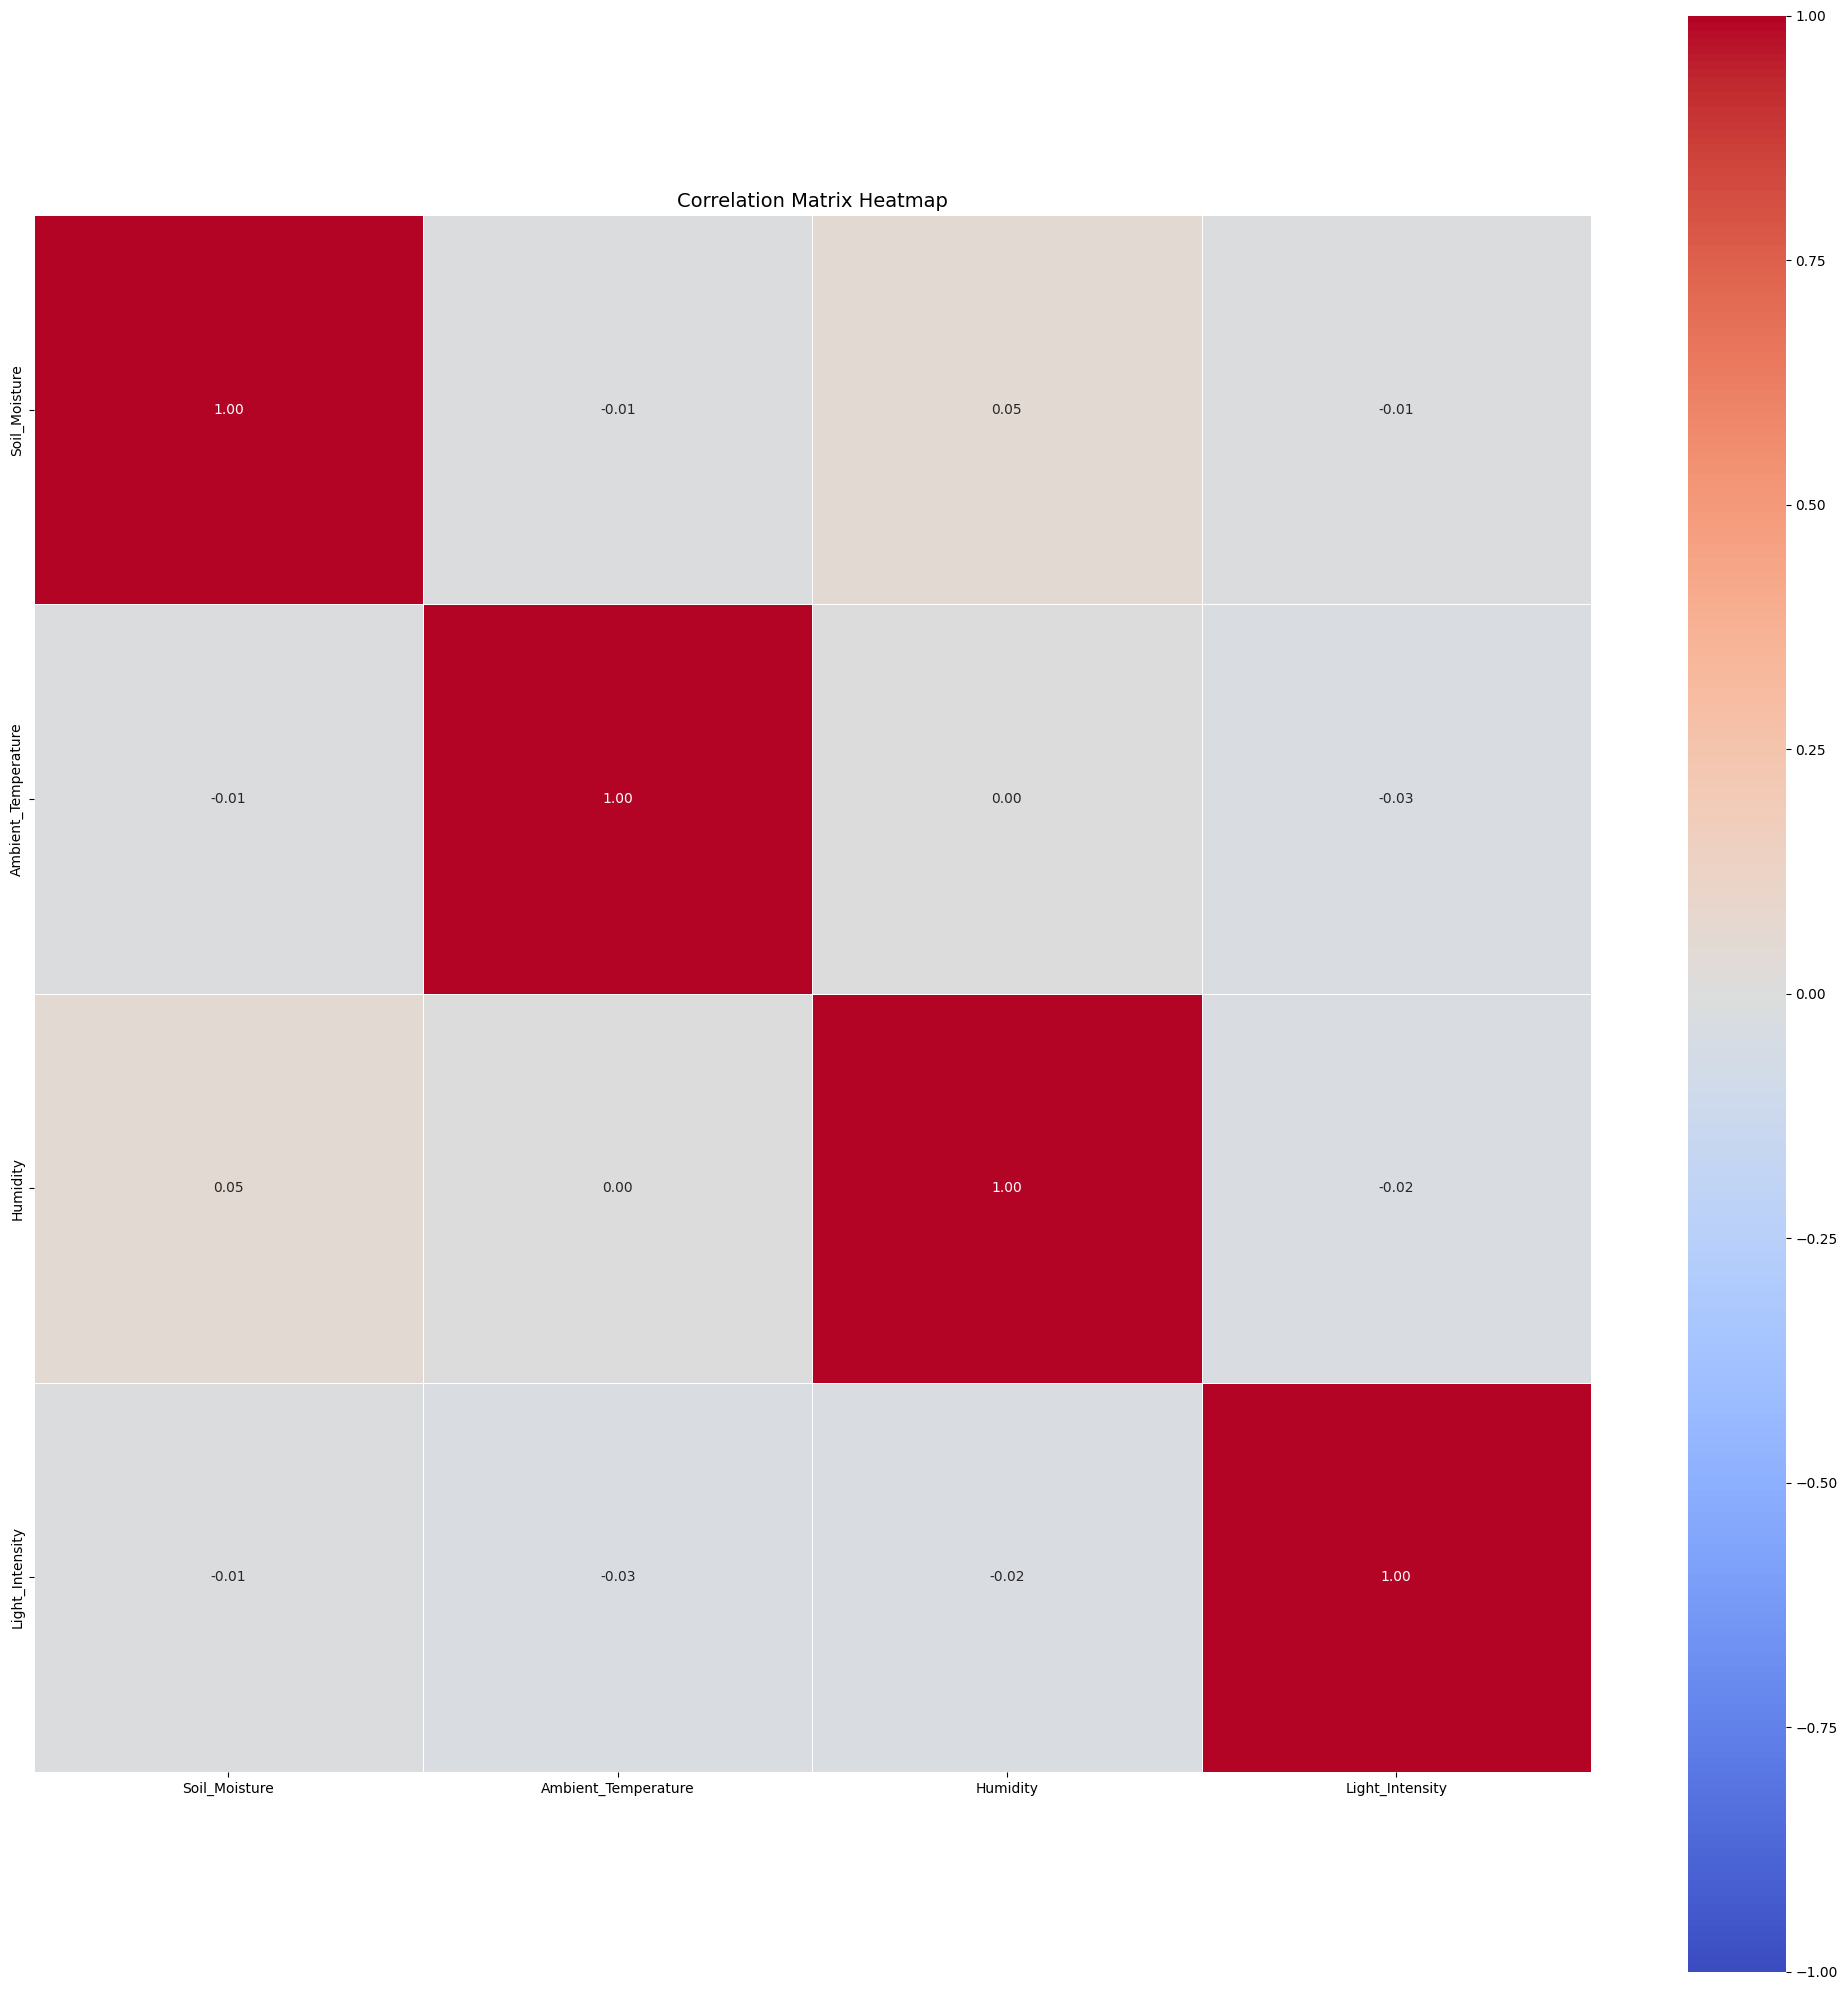

In [6]:
correlation_matrix = right_features.corr(numeric_only=True)
plt.figure(figsize=(20, 20))
sns.heatmap(
    correlation_matrix,
    annot=True,        
    fmt=".2f",         
    cmap="coolwarm",   
    vmin=-1, vmax=1,   
    linewidths=0.5,    
    square=True        
)

plt.title("Correlation Matrix Heatmap", fontsize=14)
plt.tight_layout()
plt.show()
#Very low correlations between each feature

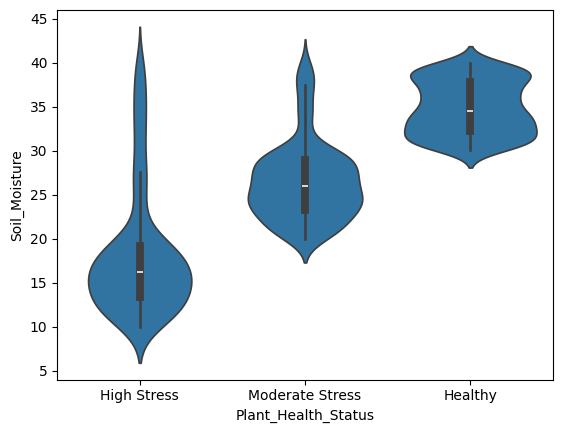

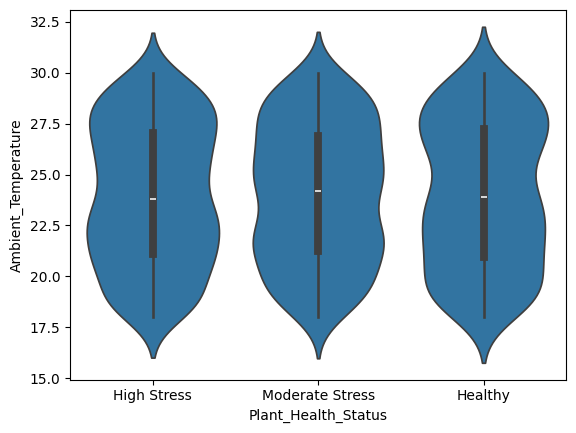

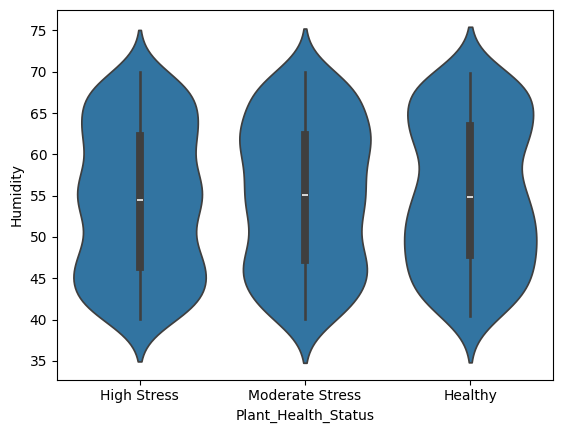

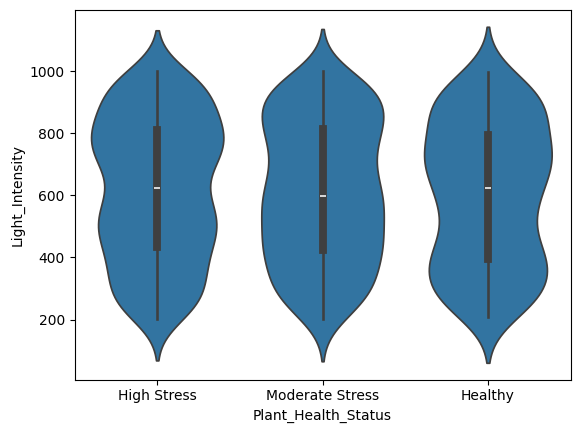

In [7]:
numeric_cols = right_features.select_dtypes(include=np.number)
#seperates numeric features out so they can be used in violin plots (there arent any in the final program so it doesnt really matter)
for col in numeric_cols:
    sns.violinplot(x='Plant_Health_Status',
                   y=col,
                   data=right_features
    )
    plt.show()

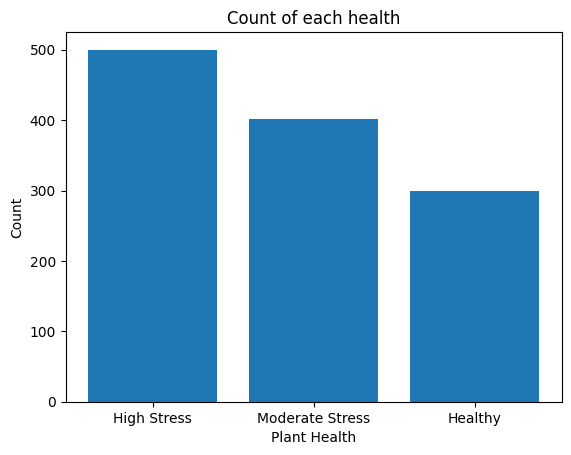

In [8]:
Health= right_features["Plant_Health_Status"].value_counts()
plt.bar(Health.index, Health.values)
plt.xlabel('Plant Health')
plt.ylabel('Count')
plt.title('Count of each health')
plt.xticks(Health.index, ['High Stress','Moderate Stress', 'Healthy'])
plt.show()

#Reasonable split but there are more less healthy plants

In [9]:
X = right_features.drop("Plant_Health_Status", axis=1)
y = right_features["Plant_Health_Status"]

X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2, stratify=y, random_state=42)
#Split the dataset so the model isnt evaluated based on data it has already seen

      Soil_Moisture  Ambient_Temperature   Humidity  Light_Intensity
775       13.870512            28.733525  57.309071       377.857929
348       23.276825            28.415199  46.345665       425.252691
183       30.767529            24.297777  68.502034       538.409071
1057      32.272308            20.131352  50.283229       229.310411
538       23.030776            19.926305  65.062826       235.662519
...             ...                  ...        ...              ...
866       28.976804            19.414941  43.528436       341.234580
398       37.630414            19.116342  66.450804       560.854236
251       32.762349            28.348042  52.579205       655.642350
62        13.744134            29.128077  59.182493       811.954589
1034      31.467383            18.267500  51.468437       331.616566

[960 rows x 4 columns]
Decision Tree Accuracy(training data): 0.8885416666666667
Decision Tree F1(training data): 0.8865563105711599
Cross-Validation Accuracy Scores: [0.8

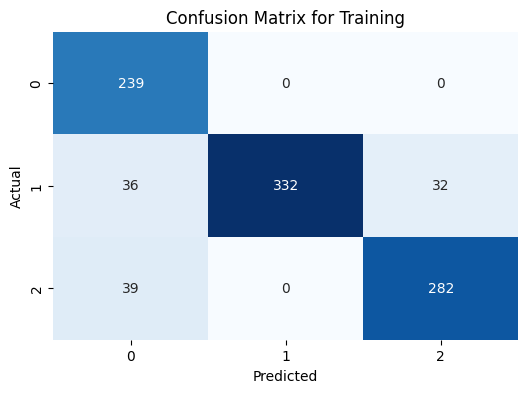

Decision Tree Accuracy (test data): 0.85
Decision Tree F1(test data): 0.849767890588085
Cross-Validation Accuracy Scores: [0.75       0.72916667 0.70833333 0.85416667 0.79166667]
Mean CV Accuracy: 0.7666666666666666


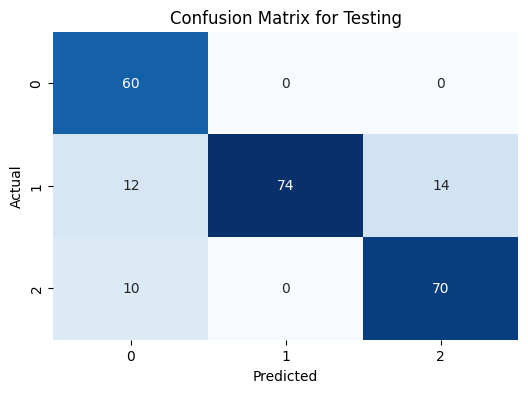

In [10]:
model = DecisionTreeClassifier(max_depth=5, random_state=42)
print(X_train)
model.fit(X_train, y_train)
#Must be tested on both splits to check overfitting

CV=5

#Predict health based on training and test data so they can both be compared
pred_test = model.predict(X_test)
pred_train = model.predict(X_train)

train_acc = metrics.accuracy_score(y_train, pred_train)
print("Decision Tree Accuracy(training data):", train_acc)

train_f1 = metrics.f1_score(y_train, pred_train,average='macro')
print("Decision Tree F1(training data):", train_f1)

cv_scores = cross_val_score(model, X_train, y_train, cv=CV)  
print("Cross-Validation Accuracy Scores:", cv_scores)
print("Mean CV Accuracy:", np.mean(cv_scores))

#Makes a confusion matrix so I can see how well it predicts and if it predicts badly I will understand how it predicts
cm = metrics.confusion_matrix(y_train, pred_train)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix for Training")
plt.show()

#Check scores with test data and train data so I can see if its overfitting or not
test_acc = metrics.accuracy_score(y_test, pred_test)
print("Decision Tree Accuracy (test data):", test_acc)

test_f1 = metrics.f1_score(y_test, pred_test,average='macro')
print("Decision Tree F1(test data):", test_f1)

cv_scores = cross_val_score(model, X_test, y_test, cv=CV)  
print("Cross-Validation Accuracy Scores:", cv_scores)
print("Mean CV Accuracy:", np.mean(cv_scores))


cm = metrics.confusion_matrix(y_test, pred_test)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix for Testing")
plt.show()

Decision Tree Accuracy(training data): 0.7947916666666667
Decision Tree F1(training data): 0.7899380262584019
Cross-Validation Accuracy Scores: [0.63020833 0.625      0.64583333 0.640625   0.65625   ]
Mean CV Accuracy: 0.6395833333333334


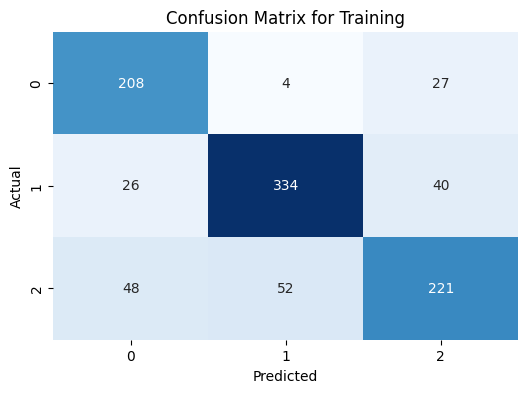

Decision Tree Accuracy (test data): 0.6
Decision Tree F1(test data): 0.5964776281789745
Cross-Validation Accuracy Scores: [0.52083333 0.39583333 0.39583333 0.41666667 0.375     ]
Mean CV Accuracy: 0.4208333333333334


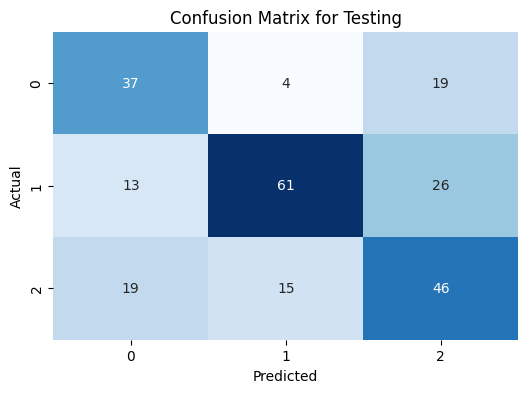

In [11]:

knn = KNeighborsClassifier(n_neighbors=5).fit(X_train, y_train)
accuracy = knn.score(X_test, y_test)
pred_test = knn.predict(X_test)
pred_train = knn.predict(X_train)

train_acc = metrics.accuracy_score(y_train, pred_train)
print("Decision Tree Accuracy(training data):", train_acc)

train_f1 = metrics.f1_score(y_train, pred_train,average='macro')
print("Decision Tree F1(training data):", train_f1)

cv_scores = cross_val_score(knn, X_train, y_train, cv=CV)  
print("Cross-Validation Accuracy Scores:", cv_scores)
print("Mean CV Accuracy:", np.mean(cv_scores))

cm = metrics.confusion_matrix(y_train, pred_train)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix for Training")
plt.show()

test_acc = metrics.accuracy_score(y_test, pred_test)
print("Decision Tree Accuracy (test data):", test_acc)

test_f1 = metrics.f1_score(y_test, pred_test,average='macro')
print("Decision Tree F1(test data):", test_f1)

cv_scores = cross_val_score(knn, X_test, y_test, cv=CV)  
print("Cross-Validation Accuracy Scores:", cv_scores)
print("Mean CV Accuracy:", np.mean(cv_scores))

cm = metrics.confusion_matrix(y_test, pred_test)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix for Testing")
plt.show()

In [12]:
with open("Plants_AI.pkl", "wb") as f:
 pickle.dump(model, f)